今まで、ずっと使ってきたJena Climate Datasetに対して、optunaの適用

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
import math

In [9]:
df=pd.read_csv("jena_climate_2009_2016.csv")
df['day']=pd.to_datetime(df['Date Time'],dayfirst=True)
df.drop("Date Time",axis=1,inplace=True)
df_day = df.resample('D', on='day').mean().reset_index()
df_nan_rows = df_day[df_day.isnull().any(axis=1)]
ideal_range = pd.date_range(start=df_day['day'].min(), end=df_day['day'].max(), freq='D')
df_indexed = df_day.set_index('day').reindex(ideal_range)
missing_dates = df_indexed[df_indexed.isnull().any(axis=1)].index
df_nonan = df_indexed.interpolate(method='linear')
df_p=df_nonan.reset_index().rename({'index':"day"},axis=1)
timestamp_s = df_p.day.map(pd.Timestamp.timestamp) 
day_seconds = 24 * 60 * 60
year_seconds = (365.2425) * day_seconds
df_p['Year_sin'] = np.sin(timestamp_s * (2 * np.pi / year_seconds))
df_p['Year_cos'] = np.cos(timestamp_s * (2 * np.pi / year_seconds))
wd_rad = df_p['wd (deg)'] * np.pi / 180
df_p['Wx'] = df_p['wv (m/s)'] * np.cos(wd_rad)
df_p['Wy'] = df_p['wv (m/s)'] * np.sin(wd_rad)
cols_to_drop = [
    'day', 
    'wv (m/s)', 'max. wv (m/s)', 'wd (deg)',
    'Tpot (K)', 'Tdew (degC)',
    'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)'
]
df_final = df_p.drop(columns=cols_to_drop)
n = len(df_final)
train_df = df_final[0:int(n*0.7)]
val_df = df_final[int(n*0.7):int(n*0.9)]
test_df = df_final[int(n*0.9):]

scaler = StandardScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

print("Trainデータの形状:", train_scaled.shape)
print("Valデータの形状:", val_scaled.shape)
print("Testデータの形状:", test_scaled.shape)
train_df = pd.DataFrame(train_scaled, columns=df_final.columns, index=train_df.index)
val_df = pd.DataFrame(val_scaled, columns=df_final.columns, index=val_df.index)
test_df = pd.DataFrame(test_scaled, columns=df_final.columns, index=test_df.index)

class data_load(Dataset):
    def __init__(self,df,input_width,label_width,shift,label_col=None):
        self.df=df
        self.input_width=input_width
        self.label_width=label_width
        self.total_window_size=input_width+shift
        self.label_columns=label_col
        if label_col is not None:
            col_ind={name:i for i,name in  enumerate(df.columns)}
            self.lab_ind=[col_ind[name] for name in self.label_columns]
        self.data = torch.tensor(df.values.astype('float32'))
    def __len__(self):
        return len(self.data)-self.total_window_size+1
    
    def __getitem__(self, i):
        window=self.data[i:i+self.total_window_size]
        inputs = window[:self.input_width, :]
        label_start = self.total_window_size - self.label_width
        labels = window[label_start:, :]
        if self.label_columns is not None:
            labels=labels[:,self.lab_ind]
        return inputs,labels

def create_dataloader(df, input_width=7, label_width=7, shift=7, batch_size=32, shuffle=False):
    dataset = data_load(
        df=df, 
        input_width=input_width, 
        label_width=label_width, 
        shift=shift, 
        label_col=label_cols  
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    return dataloader

label_cols=['T (degC)']
train_loader = create_dataloader(
    df=train_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=True
)
val_loader = create_dataloader(
    df=val_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)
test_loader = create_dataloader(
    df=test_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)

Trainデータの形状: (2046, 8)
Valデータの形状: (584, 8)
Testデータの形状: (293, 8)


以下、各変数における分布のcheck
説明変数も目的変数も似たような分布、正規分布に近いものだと、最適化の際にスムーズに進む。ただ、説明変数に関しては、そこまで気にしなくていい
また、目的変数は、損失関数にMSEを使うならば意識したほうがいい。数学的にMSEは最尤法と同値になるので、残差自体に正規性を仮定しているものだからである。
ただ、今回は、大きく分布の裾が伸びていないので問題はないとおもうが、もし伸びていたらYeo-Johnson変換(今回は値が負もあるので)してもいいかもしれない。

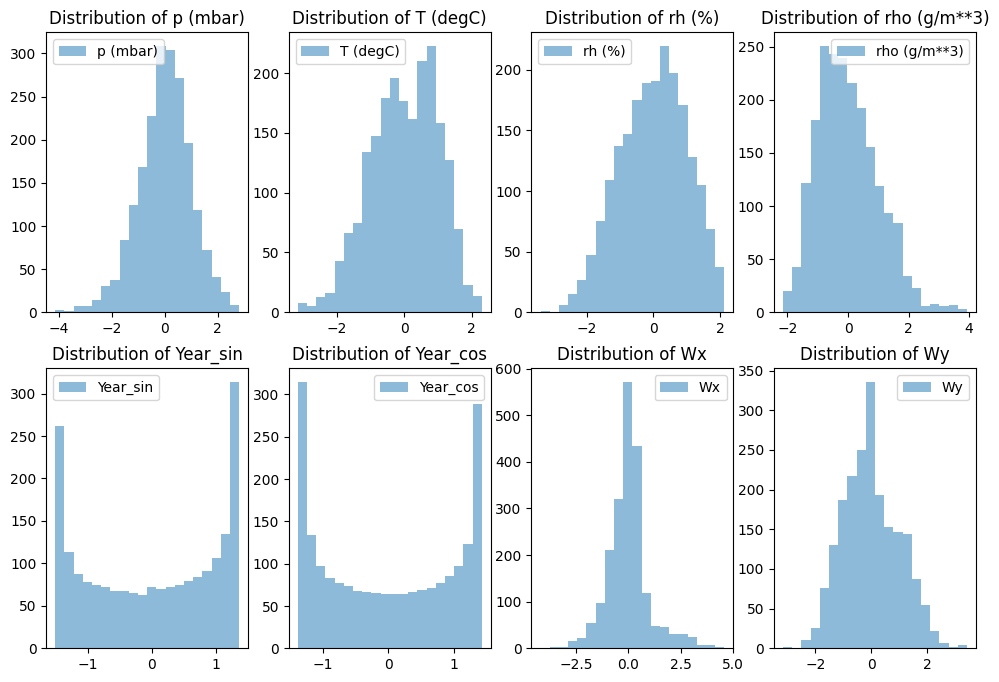

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()
for i in range(train_df.shape[1]):
    ax = axes[i]
    ax.hist(train_df.iloc[:, i], bins=20, alpha=0.5, label=train_df.columns[i])
    ax.legend()
    ax.set_title(f"Distribution of {train_df.columns[i]}")

 Adversarial Validationの検証をしてみる
時系列データなので、そもそもAUCは多少高くなるのは想定できる(入力データと出力データに関してサイズも違うので、季節性の観点から偏りがでてしまうため)
今回はスルーする。

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgb

In [12]:
df_train_raw = train_df.copy()
df_test_raw = test_df.copy()
df_train_raw['is_test'] = 0
df_test_raw['is_test'] = 1
df_adv = pd.concat([df_train_raw, df_test_raw], axis=0).reset_index(drop=True)
features = [col for col in df_adv.columns if col not in ['is_test', 'T (degC)']]
X_adv = df_adv[features]
y_adv = df_adv['is_test']
X_tr, X_va, y_tr, y_va = train_test_split(
    X_adv, y_adv, test_size=0.3, random_state=999, stratify=y_adv
)


In [13]:
train_dataset = lgb.Dataset(X_tr, label=y_tr)
val_dataset = lgb.Dataset(X_va, label=y_va)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'verbosity': -1,
    'random_state': 42
}

model = lgb.train(
    params,
    train_dataset,
    valid_sets=[val_dataset],
    num_boost_round=200,
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 予測とAUCの算出
preds = model.predict(X_va)
auc_score = roc_auc_score(y_va, preds)
print(f"--- Adversarial Validation 結果 ---")
print(f"ROC-AUC Score: {auc_score:.4f}")

--- Adversarial Validation 結果 ---
ROC-AUC Score: 0.7017


ROC-AUC Score: 0.7017の結果と特徴量の重要度を見てみる
上位に時間に関係するものが来るのは仕方ないかつ、２週間予測なのでこれの変数を消すことはない。
pに関しては見当が必要

In [14]:
importance = model.feature_importance(importance_type='gain')
df_importance = pd.DataFrame({'Feature': features, 'Gain': importance}).sort_values(by='Gain', ascending=False)
df_importance.head(10)

,Feature,Gain
0,p (mbar),497.966811
4,Year_cos,466.286987
3,Year_sin,423.053411
5,Wx,385.765747
2,rho (g/m**3),348.415310
6,Wy,139.725081
1,rh (%),130.370870


メインのoptunaを適用してみる
今回のoptunaの目的は、avg_val_lossが、小さくなるようなパラメータを求めることである。
過去にこのlossをなるべく小さくかつ、横ばいにしようとした(seikika.ipynb)実験をしたときのcode(CNN)を参考にしている。


In [15]:
class time_ser_1(nn.Module):
    def __init__(self,in_cha,conv_cha,block_dropout_p=0.1):#入力が[32,14,8]
        super().__init__()
        self.conv1=nn.Conv1d(in_cha,conv_cha,kernel_size=3,padding=1,bias=True)
        self.relu1=nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(conv_cha, conv_cha, kernel_size=3, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)
        self.avgpool = nn.AvgPool1d(2, 2) #最後の次元に作用,maxもある
        self.dropout = nn.Dropout(p=block_dropout_p)
    def forward(self,input):
        block_out=self.conv1(input)
        block_out=self.relu1(block_out)
        block_out=self.conv2(block_out)
        block_out=self.relu2(block_out)
        block_out = self.dropout(block_out)
        return self.avgpool(block_out)

class time_NN_1(nn.Module):
      def __init__(self,in_cha,conv_cha,fc_dropout_p=0.5):
          super().__init__()
          self.block1 = time_ser_1(in_cha, conv_cha)
          self.block2 = time_ser_1(conv_cha, conv_cha*2) 
          self.fc_dropout = nn.Dropout(p=fc_dropout_p)
          self.head_linear = nn.Linear(64*3, 14)
          self._init_weights()

      def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv1d}:
                nn.init.kaiming_normal_(
                    m.weight.data, a=0, mode='fan_out', nonlinearity='relu',
                )#平均0の正規分布からランダムに選ぶ
                if m.bias is not None:
                    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out)
                    nn.init.uniform_(m.bias, -bound, bound)
      def forward(self, input_batch):
            input_batch = input_batch.permute(0, 2, 1)#次元置き換え,特徴量が真ん中に来るように設定
            block_out = self.block1(input_batch)  # [B, 32, 7]
            block_out = self.block2(block_out)  # [B, 64, 3]
            conv_flat = block_out.view(block_out.size(0), -1) # [B, 96]
            conv_flat = self.fc_dropout(conv_flat)
            linear_output = self.head_linear(conv_flat)      
            kekka=linear_output.unsqueeze(-1)
            return kekka

In [ ]:
import optuna
def objective(trial):
    fc_dropout_p = trial.suggest_float('fc_dropout_p', 0.1, 0.7)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)#lrは慎重に探索
    delta = trial.suggest_float('delta', 0.1, 1.0)
    model = time_NN_1(in_cha=8, conv_cha=32, fc_dropout_p=fc_dropout_p).to("cuda")
    loss_fn = nn.HuberLoss(delta=delta)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    epoch = 50
    
    for i in range(epoch):
        model.train() 
        for inputs, labels in train_loader:
            inputs = inputs.to("cuda")
            labels = labels.to("cuda")
            
            outputs = model(inputs) 
            loss = loss_fn(outputs, labels) 
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        model.eval() 
        total_val_loss = 0
        
        with torch.no_grad(): 
            for val_inputs, val_labels in val_loader:
                val_inputs = val_inputs.to("cuda")
                val_labels = val_labels.to("cuda")
                
                val_outputs = model(val_inputs)
                val_loss = loss_fn(val_outputs, val_labels)
                total_val_loss += val_loss.item()
                
        avg_val_loss = total_val_loss / len(val_loader)
        trial.report(avg_val_loss, i)
        if trial.should_prune():#枝切り
            raise optuna.exceptions.TrialPruned()
    return avg_val_loss

print("ハイパーパラメータ探索を開始します...")
study = optuna.create_study(direction="minimize") #5エポック目の報告以降に、過去の上位25%の成績に届きそうにない場合
study.optimize(objective, n_trials=30)

print(f"最も良かったValidation Loss: {study.best_value:.4f}")
print("その時のベストパラメータ:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

[I 2026-05-30 19:51:01,048] A new study created in memory with name: no-name-33c06648-8757-489d-9608-dc278411442e


ハイパーパラメータ探索を開始します...


[I 2026-05-30 19:51:12,758] Trial 0 finished with value: 0.31494449492957854 and parameters: {'fc_dropout_p': 0.3627812031548685, 'lr': 1.2565568120492688e-05, 'delta': 0.4839922629022917}. Best is trial 0 with value: 0.31494449492957854.
[I 2026-05-30 19:51:19,241] Trial 1 finished with value: 0.5243844423029158 and parameters: {'fc_dropout_p': 0.22810251151386748, 'lr': 0.00033676012134878255, 'delta': 0.7418168391898895}. Best is trial 0 with value: 0.31494449492957854.
[I 2026-05-30 19:51:26,560] Trial 2 finished with value: 0.19607569091022015 and parameters: {'fc_dropout_p': 0.5905803640103542, 'lr': 0.00028932682864170735, 'delta': 0.3005494746541325}. Best is trial 2 with value: 0.19607569091022015.
[I 2026-05-30 19:51:33,988] Trial 3 finished with value: 0.48358691069814896 and parameters: {'fc_dropout_p': 0.5388048495942829, 'lr': 0.00041167320725019876, 'delta': 0.9123820312369654}. Best is trial 2 with value: 0.19607569091022015.
[I 2026-05-30 19:51:41,125] Trial 4 finished

最も良かったValidation Loss: 0.0615
その時のベストパラメータ:
    fc_dropout_p: 0.5021321234611249
    lr: 0.009781158078043996
    delta: 0.11402311637489991


最終モデル

In [19]:
best_params = study.best_params
print("採用するパラメータ:", best_params)

best_lr = best_params['lr']
best_delta = best_params['delta']
best_dropout = best_params['fc_dropout_p']

final_model = time_NN_1(in_cha=8, conv_cha=32, fc_dropout_p=best_dropout).to("cuda")
final_loss_fn = nn.HuberLoss(delta=best_delta)
final_optimizer = optim.Adam(final_model.parameters(), lr=best_lr)

採用するパラメータ: {'fc_dropout_p': 0.5021321234611249, 'lr': 0.009781158078043996, 'delta': 0.11402311637489991}


In [21]:
epoch = 50
train_losss2=[]
val_losss2=[]
for i in range(epoch):
    final_model.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = final_model(inputs) 
        loss = final_loss_fn(outputs, labels) 
        
        final_optimizer.zero_grad()
        loss.backward()
        final_optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losss2.append(avg_train_loss)
    final_model.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = final_model(val_inputs)
            val_loss = final_loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    val_losss2.append(avg_val_loss)

trainのlossと、valのlossの推移をみても、固定の値で探索するより、はるかに小さくなっている。
このように、簡単なモデルに対してはパラメータの複数探索は非常に有用であるかもしれない。

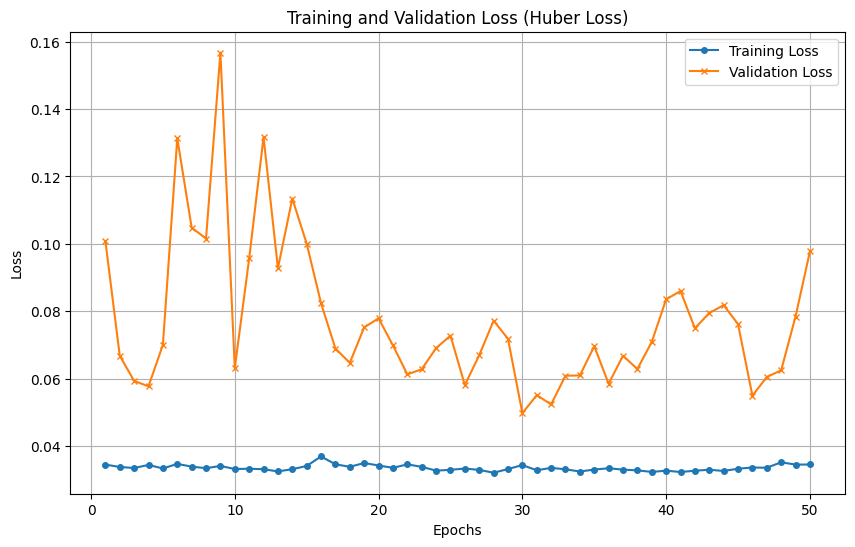

In [22]:
plt.figure(figsize=(10, 6))
epochs = range(1, epoch + 1)
plt.plot(epochs, train_losss2, label='Training Loss', marker='o', markersize=4)
plt.plot(epochs, val_losss2, label='Validation Loss', marker='x', markersize=4)
plt.title('Training and Validation Loss (Huber Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()